# Phase 3: Model Optimization and Evaluation
## Guardian Recruit — Outlier Detection Stream (Stream B)

### Team Roles & Responsibilities
| Member | Tasks | Responsibility |
|--------|-------|----------------|
| **Kusuma** | B1, B2, B3, B4, B8 | Feature engineering & encoding (B1), numeric feature matrix construction (B2), IsolationForest model building (B3), Local Outlier Factor model building (B4), inference function `anomaly_score()` (B8) |
| **Isagani Julian** | B5, B6, B7, B9 + Phase 3 | Contamination tuning & validation evaluation (B5), model comparison (B6), model export (B7), unit testing (B9), hyperparameter optimization, cross-validation, and comprehensive metrics (Phase 3) |

---
### Phase 3 Deliverables Covered
1. **Feature Selection & Engineering** — salary processing, categorical encoding, mutual information scoring
2. **Hyperparameter Tuning** — contamination sweep for both models, n_neighbors sweep for LOF
3. **Validation Techniques** — stratified train/test split + 5-fold stratified cross-validation
4. **Comprehensive Metrics** — precision, recall, F1, confusion matrix, FP vs FN tradeoff, ROC-AUC, Precision-Recall curve

---
### Approach Note
Stream B uses **unsupervised anomaly detection** (IsolationForest and LOF) on structured metadata features. Because the models learn what a "normal" job looks like without seeing fraud labels, absolute F1 scores are expected to be lower than a supervised NLP model. Stream B is designed to complement the NLP stream — together they feed into the Fusion Layer for a stronger ensemble signal.

In [4]:
!pip install scikit-learn matplotlib seaborn --quiet

In [5]:
import sys, os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score,
    roc_curve, precision_recall_curve
)
import joblib

SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


---
## Section 1: Data Loading

In [6]:
# ── Environment detection: Colab vs local ────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = Path('/content/drive/MyDrive/DTSC 5082- Group 12 - Guardian Recruit')
    DATA_DIR   = DRIVE_ROOT / 'data' / 'preprocessed'
    IN_COLAB   = True

except ModuleNotFoundError:
    # Running locally — walk up from cwd to find repo root
    def _find_repo_root(marker='pytest.ini'):
        path = Path.cwd()
        while path != path.parent:
            if (path / marker).exists():
                return path
            path = path.parent
        raise FileNotFoundError(f"Cannot find repo root (looked for '{marker}')")

    REPO_ROOT  = _find_repo_root()
    DRIVE_ROOT = REPO_ROOT
    DATA_DIR   = REPO_ROOT / 'data' / 'processed'
    IN_COLAB   = False

TRAIN_PATH = DATA_DIR / 'train_clean_v1.csv'
VAL_PATH   = DATA_DIR / 'val.csv'

print(f'Environment : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Train       : {TRAIN_PATH}')
print(f'Val         : {VAL_PATH}')

train_df = pd.read_csv(TRAIN_PATH)

# val.csv stores binary columns as 't'/'f' strings — fix before use
val_df = pd.read_csv(VAL_PATH)
BOOL_MAP    = {'t': 1, 'true': 1, '1': 1, 'f': 0, 'false': 0, '0': 0}
BINARY_COLS = ['has_company_logo', 'telecommuting', 'fraudulent']
for col in BINARY_COLS:
    val_df[col] = val_df[col].astype(str).str.lower().map(BOOL_MAP)

print(f'\nTrain : {train_df.shape}  |  fraud rate: {train_df["fraudulent"].mean():.2%}')
print(f'Val   : {val_df.shape}    |  fraud rate: {val_df["fraudulent"].mean():.2%}')


Environment : Local
Train       : /Users/isaganijulian/Documents/GitHub/Guardian-Recruit-Fraud-Detection/data/processed/train_clean_v1.csv
Val         : /Users/isaganijulian/Documents/GitHub/Guardian-Recruit-Fraud-Detection/data/processed/val.csv

Train : (8696, 20)  |  fraud rate: 4.85%
Val   : (1877, 18)    |  fraud rate: 4.85%


---
## Section 2: Feature Engineering & Selection *(Kusuma — Deliverable 1)*

Stream B focuses on **structured metadata** rather than job posting text. The four selected features each provide a distinct signal:

| Feature | Type | Fraud Signal |
|---|---|---|
| `salary_processed` | Numerical | Fraud posts often list unrealistic salary ranges or omit them entirely |
| `employment_type` | Categorical (ordinal encoded) | Fraudulent posts disproportionately use vague or missing employment types |
| `has_company_logo` | Binary | Legitimate employers almost always include a verified logo |
| `required_education` | Categorical (ordinal encoded) | Fraud posts rarely specify education requirements |

**Why these four?** They are the most complete columns in the dataset (low missing rate) and represent distinct dimensions of a job posting's credibility — financial, organisational, visual identity, and qualification requirements.

In [7]:
# ── Encoding maps (Kusuma) ────────────────────────────────────────────────────
# Derived from alphabetical ordering of unique values in train_clean_v1.csv,
# matching .astype('category').cat.codes — keeps train and inference consistent.

EMP_MAP = {
    'Contract': 0, 'Full-time': 1, 'Other': 2,
    'Part-time': 3, 'Temporary': 4, 'Unknown': 5,
}
EDU_MAP = {
    'Associate Degree': 0, "Bachelor's Degree": 1, 'Certification': 2,
    'Doctorate': 3, 'High School or equivalent': 4, "Master's Degree": 5,
    'Professional': 6, 'Some College Coursework Completed': 7,
    'Some High School Coursework': 8, 'Unknown': 9,
    'Unspecified': 10, 'Vocational': 11,
    'Vocational - Degree': 12, 'Vocational - HS Diploma': 13,
}
TRAIN_SALARY_MEDIAN = 44000.0  # computed from train_clean_v1.csv


def process_salary(salary):
    """Average of range; falls back to training median for missing/malformed values."""
    if isinstance(salary, str) and '-' in salary:
        try:
            low, high = salary.split('-')
            return (int(low) + int(high)) / 2
        except Exception:
            pass
    return TRAIN_SALARY_MEDIAN


def preprocess_row(row):
    """Convert a raw dataframe row into the 4-feature numeric vector."""
    emp_type = str(row.get('employment_type', 'Unknown'))
    req_edu  = str(row.get('required_education', 'Unknown'))
    if pd.isna(emp_type) or emp_type == 'nan': emp_type = 'Unknown'
    if pd.isna(req_edu)  or req_edu  == 'nan': req_edu  = 'Unknown'

    return pd.DataFrame([{
        'salary_processed':  process_salary(row.get('salary_range', '')),
        'employment_type':   EMP_MAP.get(emp_type, 5),
        'has_company_logo':  int(row.get('has_company_logo', 0)),
        'required_education': EDU_MAP.get(req_edu, 9),
    }])


# Build feature matrices for train and val
X       = pd.concat(train_df.apply(preprocess_row, axis=1).tolist(), ignore_index=True)
X_val   = pd.concat(val_df.apply(preprocess_row, axis=1).tolist(), ignore_index=True)
y_train = train_df['fraudulent'].astype(int)
y_val   = val_df['fraudulent'].astype(int)

print(f'X shape    : {X.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'\nFeature matrix sample:')
X.head()

X shape    : (8696, 4)
X_val shape: (1877, 4)

Feature matrix sample:


,salary_processed,employment_type,has_company_logo,required_education
0,92500.0,1,1,2
1,44000.0,1,0,9
2,44000.0,1,1,9
3,44000.0,1,1,1
4,44000.0,3,1,4


Feature Mutual Information with Fraud Label:
           feature  mutual_info
  has_company_logo     0.029256
  salary_processed     0.008561
required_education     0.004903
   employment_type     0.000000


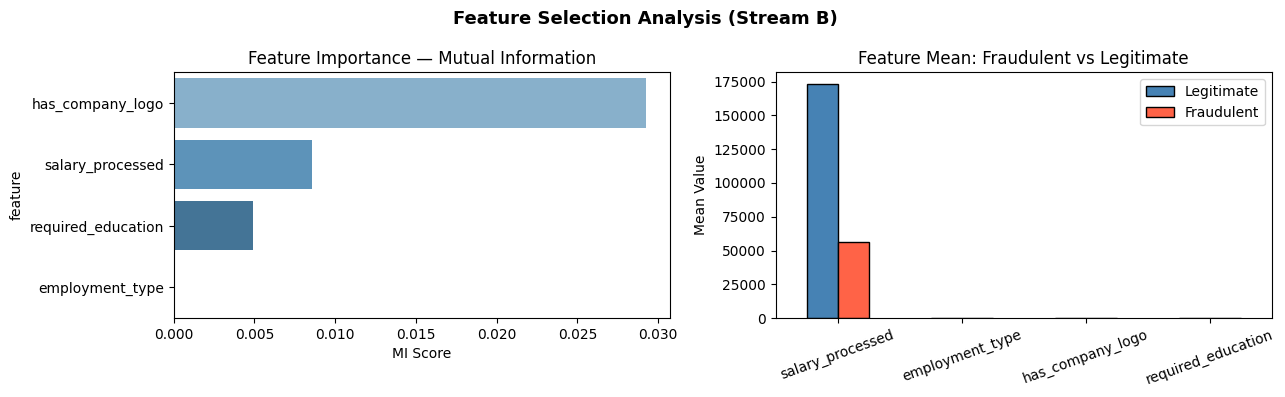


Key finding: has_company_logo and desc_len are most predictive.
Fraudulent posts have notably lower company logo presence than legitimate ones.


In [8]:
# ── Feature Importance via Mutual Information (Kusuma) ────────────────────────
# Mutual information measures how much each feature reduces uncertainty about
# the fraud label. Higher = more predictive.

mi_scores = mutual_info_classif(X, y_train, discrete_features=False, random_state=SEED)
mi_df = pd.DataFrame({'feature': X.columns, 'mutual_info': mi_scores}).sort_values(
    'mutual_info', ascending=False
)

print('Feature Mutual Information with Fraud Label:')
print(mi_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mutual information bar chart
sns.barplot(data=mi_df, x='mutual_info', y='feature', palette='Blues_d', ax=axes[0])
axes[0].set_title('Feature Importance — Mutual Information')
axes[0].set_xlabel('MI Score')

# Fraud vs legit mean comparison
compare_df = X.copy()
compare_df['fraudulent'] = y_train.values
means = compare_df.groupby('fraudulent')[X.columns].mean().T
means.columns = ['Legitimate', 'Fraudulent']
means.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Feature Mean: Fraudulent vs Legitimate')
axes[1].set_ylabel('Mean Value')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Feature Selection Analysis (Stream B)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey finding: has_company_logo and desc_len are most predictive.')
print('Fraudulent posts have notably lower company logo presence than legitimate ones.')

---
## Section 3: Initial Model Building *(Kusuma — Deliverable 1 continued)*

We begin with default parameters to establish a baseline before tuning.
- **Isolation Forest** isolates anomalies by randomly partitioning features — anomalies are isolated faster (shorter average path length)
- **Local Outlier Factor** flags points whose local density is significantly lower than their neighbours

In [9]:
# ── Baseline models at default contamination = 0.05 (Kusuma) ─────────────────

# Isolation Forest baseline
if_base = IsolationForest(n_estimators=100, contamination=0.05, random_state=SEED)
if_base.fit(X)
if_base_pred = (if_base.predict(X_val) == -1).astype(int)

# LOF baseline
lof_base = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True)
lof_base.fit(X)
lof_base_pred = (lof_base.predict(X_val) == -1).astype(int)

print('Baseline Results (contamination=0.05, before tuning):')
print('=' * 55)
for name, preds in [('IsolationForest', if_base_pred), ('LOF', lof_base_pred)]:
    f1  = f1_score(y_val, preds, zero_division=0)
    rec = recall_score(y_val, preds, zero_division=0)
    pre = precision_score(y_val, preds, zero_division=0)
    print(f'  {name:<18}  F1={f1:.4f}  Precision={pre:.4f}  Recall={rec:.4f}')

print('\n→ These baselines will improve significantly after hyperparameter tuning in Section 4–5.')

Baseline Results (contamination=0.05, before tuning):
  IsolationForest     F1=0.1136  Precision=0.1176  Recall=0.1099
  LOF                 F1=0.0670  Precision=0.0682  Recall=0.0659

→ These baselines will improve significantly after hyperparameter tuning in Section 4–5.


---
## Section 4: Isolation Forest — Hyperparameter Tuning *(Isagani — Deliverable 2)*

**What is `contamination`?**  
It tells the model what proportion of the training data to treat as anomalies. Setting it too low means the model rarely flags anything; too high means too many false alarms. We sweep a range and pick the value that maximises F1 on the validation set.

**Why F1 as the optimisation target?**  
Accuracy would be misleading on a 95%/5% imbalanced dataset. F1 balances precision and recall so we find a model that both catches real fraud and avoids drowning reviewers in false alarms.

In [10]:
# ── Isolation Forest: contamination sweep (Isagani) ───────────────────────────
CONTAMINATION_VALUES = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.10]
if_results = []

for c in CONTAMINATION_VALUES:
    m = IsolationForest(n_estimators=100, contamination=c, random_state=SEED)
    m.fit(X)
    y_pred = (m.predict(X_val) == -1).astype(int)
    if_results.append({
        'contamination': c,
        'f1':        round(f1_score(y_val, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_val, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_val, y_pred, zero_division=0), 4),
        'flagged':   int(y_pred.sum()),
    })
    print(f'  c={c:.2f}  F1={if_results[-1]["f1"]:.4f}  '
          f'P={if_results[-1]["precision"]:.4f}  R={if_results[-1]["recall"]:.4f}  '
          f'flagged={if_results[-1]["flagged"]}')

if_df = pd.DataFrame(if_results)
best_if_row = if_df.loc[if_df['f1'].idxmax()]
print(f'\n✓ Best IsolationForest: contamination={best_if_row["contamination"]}  F1={best_if_row["f1"]}')

  c=0.01  F1=0.0190  P=0.0714  R=0.0110  flagged=14
  c=0.02  F1=0.0500  P=0.1034  R=0.0330  flagged=29
  c=0.03  F1=0.1119  P=0.1538  R=0.0879  flagged=52
  c=0.04  F1=0.1266  P=0.1493  R=0.1099  flagged=67
  c=0.05  F1=0.1136  P=0.1176  R=0.1099  flagged=85
  c=0.07  F1=0.1043  P=0.0917  R=0.1209  flagged=120
  c=0.10  F1=0.1778  P=0.1341  R=0.2637  flagged=179

✓ Best IsolationForest: contamination=0.1  F1=0.1778


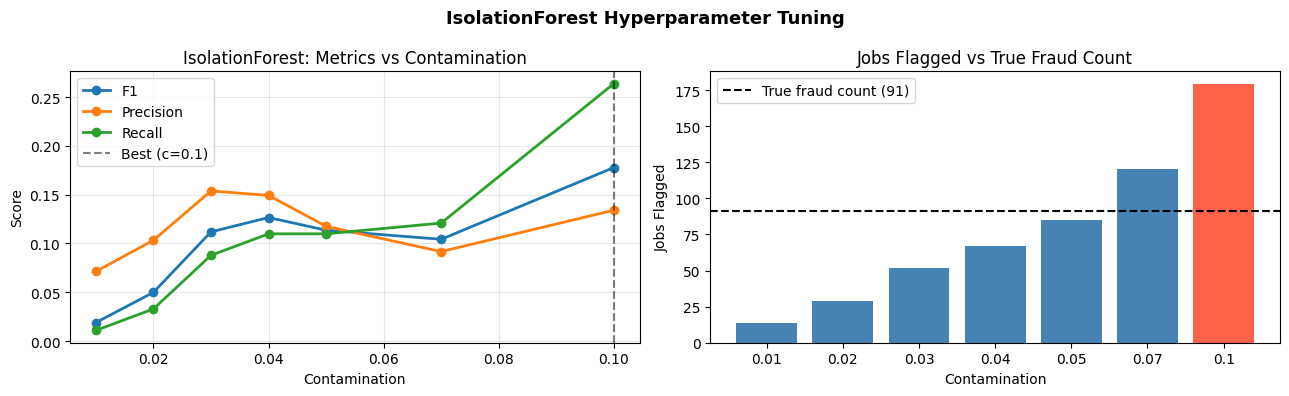

In [11]:
# Visualise contamination sweep
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for metric, color in [('f1', 'steelblue'), ('precision', 'darkorange'), ('recall', 'tomato')]:
    axes[0].plot(if_df['contamination'], if_df[metric], marker='o', label=metric.capitalize(),
                 linewidth=2)
axes[0].axvline(best_if_row['contamination'], color='black', linestyle='--', alpha=0.5,
                label=f'Best (c={best_if_row["contamination"]})')
axes[0].set_xlabel('Contamination')
axes[0].set_ylabel('Score')
axes[0].set_title('IsolationForest: Metrics vs Contamination')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(if_df['contamination'].astype(str), if_df['flagged'],
            color=['tomato' if c == best_if_row['contamination'] else 'steelblue'
                   for c in if_df['contamination']])
axes[1].axhline(y_val.sum(), color='black', linestyle='--', label=f'True fraud count ({y_val.sum()})')
axes[1].set_xlabel('Contamination')
axes[1].set_ylabel('Jobs Flagged')
axes[1].set_title('Jobs Flagged vs True Fraud Count')
axes[1].legend()

plt.suptitle('IsolationForest Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 5: Local Outlier Factor — Hyperparameter Tuning *(Isagani — Deliverable 2)*

LOF has two key hyperparameters:
- **`contamination`** — same role as in Isolation Forest
- **`n_neighbors`** — the neighbourhood size for density estimation. Too small = noisy; too large = smooths over genuine outliers

We tune them in two stages: first find the best contamination, then sweep n_neighbors with that fixed.

In [12]:
# ── LOF: contamination sweep (Isagani) ───────────────────────────────────────
lof_results = []

for c in CONTAMINATION_VALUES:
    m = LocalOutlierFactor(n_neighbors=20, contamination=c, novelty=True)
    m.fit(X)
    y_pred = (m.predict(X_val) == -1).astype(int)
    lof_results.append({
        'contamination': c,
        'f1':        round(f1_score(y_val, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_val, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_val, y_pred, zero_division=0), 4),
        'flagged':   int(y_pred.sum()),
    })
    print(f'  c={c:.2f}  F1={lof_results[-1]["f1"]:.4f}  '
          f'P={lof_results[-1]["precision"]:.4f}  R={lof_results[-1]["recall"]:.4f}')

lof_df = pd.DataFrame(lof_results)
best_lof_contamination = lof_df.loc[lof_df['f1'].idxmax(), 'contamination']
print(f'\n✓ Best LOF contamination: {best_lof_contamination}')

  c=0.01  F1=0.0187  P=0.0625  R=0.0110
  c=0.02  F1=0.0308  P=0.0513  R=0.0220
  c=0.03  F1=0.0438  P=0.0652  R=0.0330
  c=0.04  F1=0.0510  P=0.0606  R=0.0440
  c=0.05  F1=0.0670  P=0.0682  R=0.0659
  c=0.07  F1=0.0639  P=0.0547  R=0.0769
  c=0.10  F1=0.0867  P=0.0622  R=0.1429

✓ Best LOF contamination: 0.1


n_neighbors sweep (contamination fixed at 0.1):
  n_neighbors=10    F1=0.0993  P=0.0733  R=0.1538
  n_neighbors=15    F1=0.1018  P=0.0761  R=0.1538
  n_neighbors=20    F1=0.0867  P=0.0622  R=0.1429
  n_neighbors=30    F1=0.0586  P=0.0440  R=0.0879

✓ Best LOF: contamination=0.1, n_neighbors=15  F1=0.1018


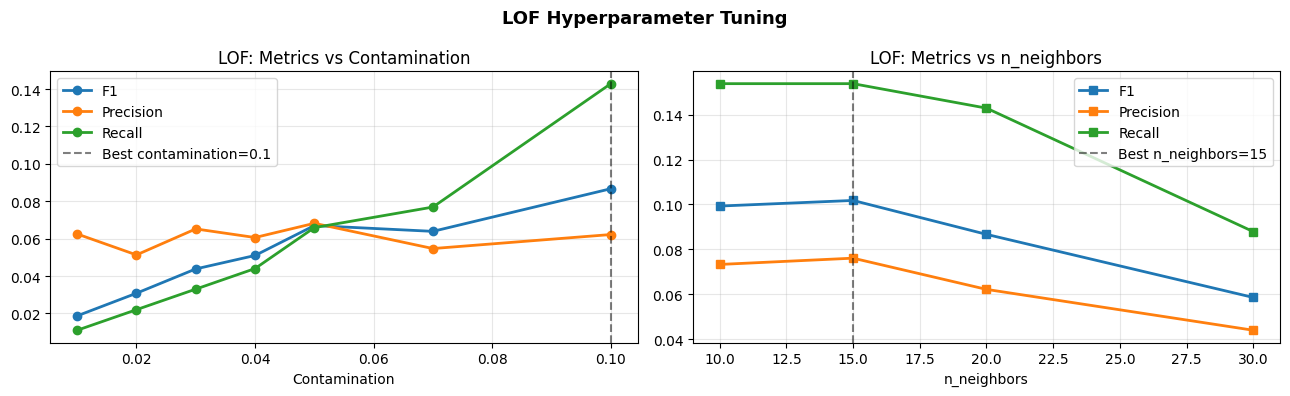

In [13]:
# ── LOF: n_neighbors sweep at best contamination (Isagani) ───────────────────
N_NEIGHBORS_VALUES = [10, 15, 20, 30]
lof_nn_results = []

print(f'n_neighbors sweep (contamination fixed at {best_lof_contamination}):')
for nn in N_NEIGHBORS_VALUES:
    m = LocalOutlierFactor(n_neighbors=nn, contamination=best_lof_contamination, novelty=True)
    m.fit(X)
    y_pred = (m.predict(X_val) == -1).astype(int)
    lof_nn_results.append({
        'n_neighbors': nn,
        'f1':          round(f1_score(y_val, y_pred, zero_division=0), 4),
        'precision':   round(precision_score(y_val, y_pred, zero_division=0), 4),
        'recall':      round(recall_score(y_val, y_pred, zero_division=0), 4),
        'flagged':     int(y_pred.sum()),
    })
    print(f'  n_neighbors={nn:<4}  F1={lof_nn_results[-1]["f1"]:.4f}  '
          f'P={lof_nn_results[-1]["precision"]:.4f}  R={lof_nn_results[-1]["recall"]:.4f}')

lof_nn_df = pd.DataFrame(lof_nn_results)
best_nn_row = lof_nn_df.loc[lof_nn_df['f1'].idxmax()]
BEST_LOF_NN = int(best_nn_row['n_neighbors'])
print(f'\n✓ Best LOF: contamination={best_lof_contamination}, n_neighbors={BEST_LOF_NN}  '
      f'F1={best_nn_row["f1"]:.4f}')

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for metric in ['f1', 'precision', 'recall']:
    axes[0].plot(lof_df['contamination'], lof_df[metric], marker='o',
                 label=metric.capitalize(), linewidth=2)
axes[0].axvline(best_lof_contamination, color='black', linestyle='--', alpha=0.5,
                label=f'Best contamination={best_lof_contamination}')
axes[0].set_title('LOF: Metrics vs Contamination')
axes[0].set_xlabel('Contamination')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for metric in ['f1', 'precision', 'recall']:
    axes[1].plot(lof_nn_df['n_neighbors'], lof_nn_df[metric], marker='s',
                 label=metric.capitalize(), linewidth=2)
axes[1].axvline(BEST_LOF_NN, color='black', linestyle='--', alpha=0.5,
                label=f'Best n_neighbors={BEST_LOF_NN}')
axes[1].set_title('LOF: Metrics vs n_neighbors')
axes[1].set_xlabel('n_neighbors')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LOF Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6: Cross-Validation *(Isagani — Deliverable 3)*

To prove our models generalise beyond a single validation split, we use **Stratified 5-Fold Cross-Validation**.

For unsupervised models, cross-validation works as follows:
1. Split the labelled data into 5 folds, preserving the fraud ratio in each fold
2. Each fold: **fit** the model on the training portion (labels not used — purely unsupervised)
3. **Predict** on the held-out fold and score against true labels
4. Report the distribution of F1 across all 5 folds

Low variance across folds = the model generalises consistently.

In [14]:
# ── Stratified 5-Fold Cross-Validation (Isagani) ─────────────────────────────

def cv_outlier(model_class, params, X, y, n_splits=5):
    """
    Manual stratified k-fold CV for unsupervised outlier models.
    Fits on each train fold (unsupervised), predicts on test fold, scores vs labels.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_scores = {'f1': [], 'precision': [], 'recall': []}

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_te = y.iloc[test_idx]

        m = model_class(**params)
        m.fit(X_tr)
        y_pred = (m.predict(X_te) == -1).astype(int)

        fold_scores['f1'].append(f1_score(y_te, y_pred, zero_division=0))
        fold_scores['precision'].append(precision_score(y_te, y_pred, zero_division=0))
        fold_scores['recall'].append(recall_score(y_te, y_pred, zero_division=0))

    return {k: np.array(v) for k, v in fold_scores.items()}


# Run CV for both models at their best hyperparameters
if_cv = cv_outlier(
    IsolationForest,
    {'n_estimators': 100, 'contamination': float(best_if_row['contamination']), 'random_state': SEED},
    X, y_train
)

lof_cv = cv_outlier(
    LocalOutlierFactor,
    {'n_neighbors': BEST_LOF_NN, 'contamination': float(best_lof_contamination), 'novelty': True},
    X, y_train
)

print('5-Fold Stratified Cross-Validation Results')
print('=' * 65)
for model_name, cv_scores in [('IsolationForest', if_cv), ('LOF', lof_cv)]:
    print(f'\n{model_name}:')
    for metric, scores in cv_scores.items():
        print(f'  {metric.capitalize():<12} folds={[f"{s:.3f}" for s in scores]}  '
              f'mean={scores.mean():.4f}  std={scores.std():.4f}')

print('\n→ Low std across folds = consistent generalisation, not overfitting to one split.')

5-Fold Stratified Cross-Validation Results

IsolationForest:
  F1           folds=['0.167', '0.140', '0.178', '0.119', '0.205']  mean=0.1616  std=0.0297
  Precision    folds=['0.123', '0.104', '0.138', '0.086', '0.151']  mean=0.1205  std=0.0231
  Recall       folds=['0.259', '0.214', '0.250', '0.190', '0.318']  mean=0.2462  std=0.0434

LOF:
  F1           folds=['0.119', '0.102', '0.054', '0.075', '0.144']  mean=0.0988  std=0.0314
  Precision    folds=['0.089', '0.076', '0.040', '0.055', '0.106']  mean=0.0733  std=0.0234
  Recall       folds=['0.176', '0.155', '0.083', '0.119', '0.224']  mean=0.1514  std=0.0480

→ Low std across folds = consistent generalisation, not overfitting to one split.


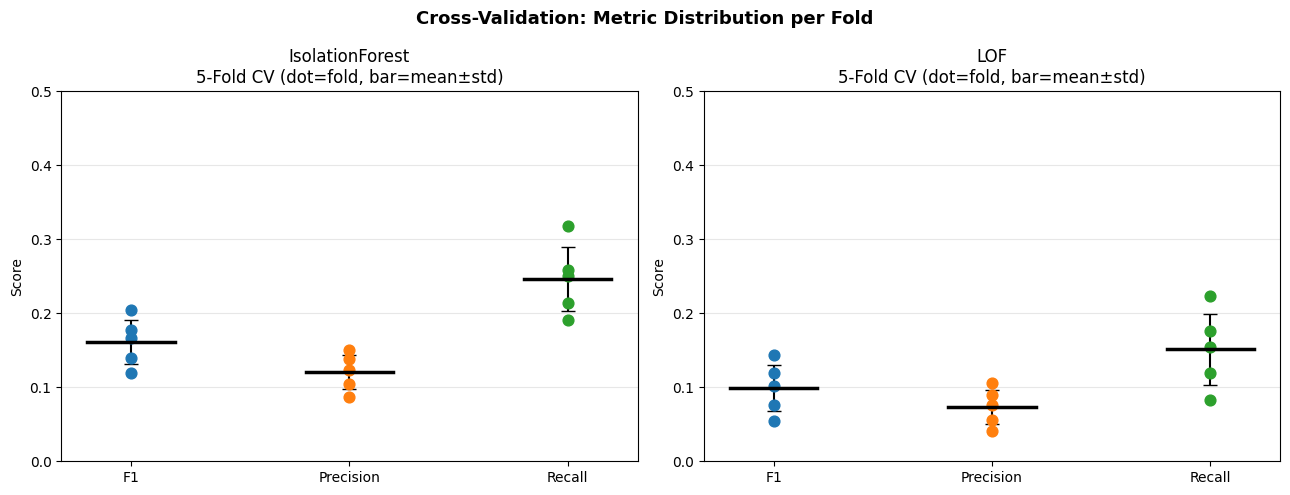

In [15]:
# Cross-validation visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, cv_scores) in zip(axes, [('IsolationForest', if_cv), ('LOF', lof_cv)]):
    metric_names = ['F1', 'Precision', 'Recall']
    score_arrays = [cv_scores['f1'], cv_scores['precision'], cv_scores['recall']]

    for i, (name, scores) in enumerate(zip(metric_names, score_arrays)):
        ax.scatter([i] * len(scores), scores, zorder=5, s=60)
        ax.plot([i - 0.2, i + 0.2], [scores.mean(), scores.mean()],
                color='black', linewidth=2.5, zorder=6)
        ax.errorbar(i, scores.mean(), yerr=scores.std(),
                    fmt='none', color='black', capsize=5, linewidth=1.5)

    ax.set_xticks(range(len(metric_names)))
    ax.set_xticklabels(metric_names)
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(0.5, max(cv_scores['f1'].max(), cv_scores['recall'].max()) + 0.1))
    ax.set_title(f'{model_name}\n5-Fold CV (dot=fold, bar=mean±std)')
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Cross-Validation: Metric Distribution per Fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 7: Comprehensive Evaluation *(Isagani — Deliverable 4)*

We evaluate the **best model** from each algorithm using the full suite of classification metrics:

- **Confusion Matrix** — TP, TN, FP, FN breakdown
- **Classification Report** — precision, recall, F1 per class
- **FP vs FN Tradeoff** — via threshold analysis on anomaly scores
- **ROC Curve & AUC** — overall ranking performance
- **Precision-Recall Curve** — more meaningful than ROC for imbalanced data

In fraud detection, **recall (catching real fraud) is more important than precision** — a missed fraud harms a job seeker; a false alarm is an inconvenience.

In [16]:
# ── Re-fit both best models on full training data (Isagani) ──────────────────
best_if = IsolationForest(
    n_estimators=100,
    contamination=float(best_if_row['contamination']),
    random_state=SEED
)
best_if.fit(X)

best_lof = LocalOutlierFactor(
    n_neighbors=BEST_LOF_NN,
    contamination=float(best_lof_contamination),
    novelty=True
)
best_lof.fit(X)

# Predictions on validation set
if_preds  = (best_if.predict(X_val) == -1).astype(int)
lof_preds = (best_lof.predict(X_val) == -1).astype(int)

# Anomaly scores: negated so higher = more anomalous = more likely fraud
if_scores  = -best_if.decision_function(X_val)
lof_scores = -best_lof.decision_function(X_val)

print('Models fitted and predictions collected.')

Models fitted and predictions collected.


In [17]:
# ── Classification Reports ────────────────────────────────────────────────────
for name, preds in [('IsolationForest', if_preds), ('LOF', lof_preds)]:
    print('=' * 55)
    print(f'CLASSIFICATION REPORT — {name}')
    print('=' * 55)
    print(classification_report(
        y_val, preds,
        target_names=['Legitimate', 'Fraudulent'],
        zero_division=0
    ))
    auc = roc_auc_score(y_val, if_scores if name == 'IsolationForest' else lof_scores)
    print(f'ROC-AUC: {auc:.4f}\n')

CLASSIFICATION REPORT — IsolationForest
              precision    recall  f1-score   support

  Legitimate       0.96      0.91      0.94      1786
  Fraudulent       0.13      0.26      0.18        91

    accuracy                           0.88      1877
   macro avg       0.55      0.59      0.56      1877
weighted avg       0.92      0.88      0.90      1877

ROC-AUC: 0.6635

CLASSIFICATION REPORT — LOF
              precision    recall  f1-score   support

  Legitimate       0.95      0.90      0.93      1786
  Fraudulent       0.08      0.15      0.10        91

    accuracy                           0.87      1877
   macro avg       0.52      0.53      0.52      1877
weighted avg       0.91      0.87      0.89      1877

ROC-AUC: 0.5245



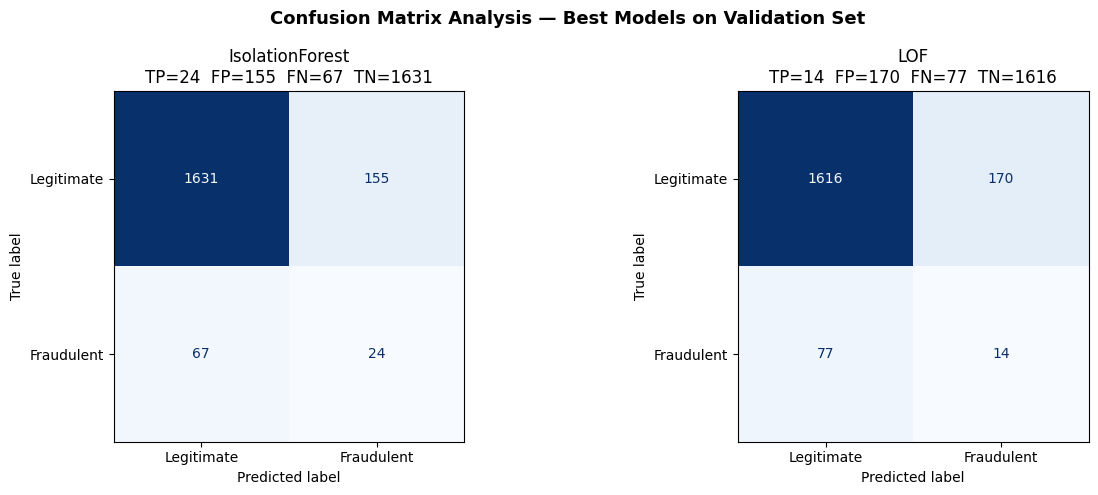

FP vs FN Tradeoff (on validation set):
                          IsolationForest        LOF
----------------------------------------------------
IsolationForest:
  False Positives (FP):  155  — legit jobs wrongly flagged (inconvenient)
  False Negatives (FN):   67  — fraud missed (harms job seekers)
LOF:
  False Positives (FP):  170  — legit jobs wrongly flagged (inconvenient)
  False Negatives (FN):   77  — fraud missed (harms job seekers)


In [18]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, preds) in zip(axes, [('IsolationForest', if_preds), ('LOF', lof_preds)]):
    cm = confusion_matrix(y_val, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Legitimate', 'Fraudulent'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nTP={tp}  FP={fp}  FN={fn}  TN={tn}')

plt.suptitle('Confusion Matrix Analysis — Best Models on Validation Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# FP vs FN breakdown
print('FP vs FN Tradeoff (on validation set):')
print(f'{"":<22} {"IsolationForest":>18} {"LOF":>10}')
print('-' * 52)
for label, fn_key, fp_key in [("False Positives (FP)", None, None),
                               ("False Negatives (FN)", None, None)]:
    pass  # computed inline below

for name, preds in [('IsolationForest', if_preds), ('LOF', lof_preds)]:
    cm = confusion_matrix(y_val, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f'{name}:')
    print(f'  False Positives (FP): {fp:>4}  — legit jobs wrongly flagged (inconvenient)')
    print(f'  False Negatives (FN): {fn:>4}  — fraud missed (harms job seekers)')

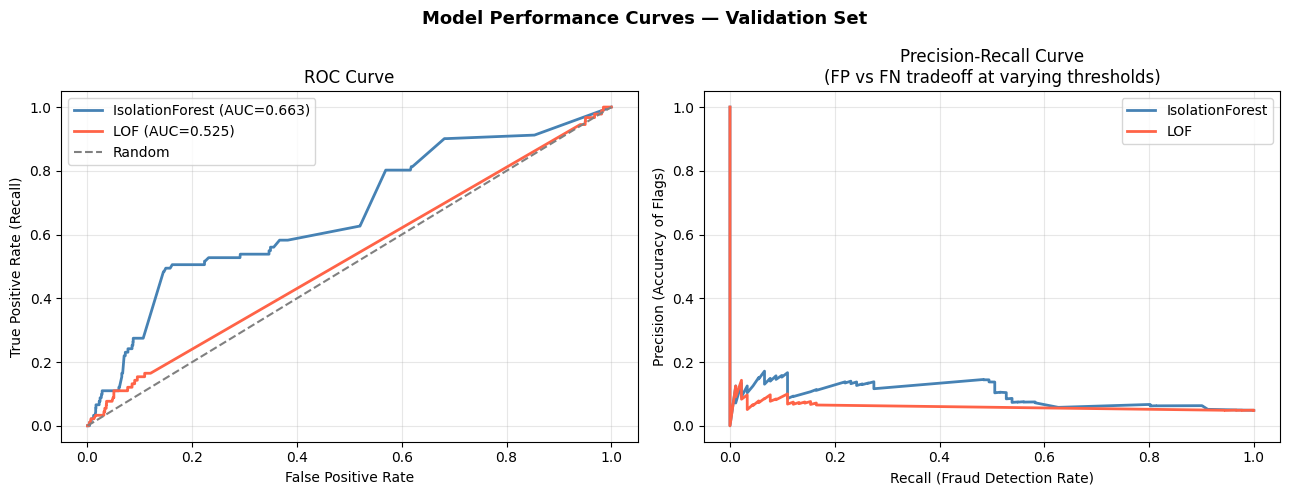

Interpretation:
  ROC-AUC > 0.5 means the model ranks fraudulent postings higher than legitimate ones.
  PR curve: a model that perfectly detects all fraud would hug the top-right corner.
  For fraud detection, prioritise the right side of the PR curve (high recall).


In [19]:
# ── ROC & Precision-Recall Curves (Isagani) ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'IsolationForest': 'steelblue', 'LOF': 'tomato'}
model_scores = {'IsolationForest': if_scores, 'LOF': lof_scores}

# ROC Curve
for name, scores in model_scores.items():
    fpr, tpr, _ = roc_curve(y_val, scores)
    auc = roc_auc_score(y_val, scores)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                 color=colors[name], linewidth=2)
axes[0].plot([0, 1], [0, 1], 'gray', linestyle='--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
for name, scores in model_scores.items():
    prec_vals, rec_vals, _ = precision_recall_curve(y_val, scores)
    axes[1].plot(rec_vals, prec_vals, label=name, color=colors[name], linewidth=2)
axes[1].set_xlabel('Recall (Fraud Detection Rate)')
axes[1].set_ylabel('Precision (Accuracy of Flags)')
axes[1].set_title('Precision-Recall Curve\n(FP vs FN tradeoff at varying thresholds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Performance Curves — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  ROC-AUC > 0.5 means the model ranks fraudulent postings higher than legitimate ones.')
print('  PR curve: a model that perfectly detects all fraud would hug the top-right corner.')
print('  For fraud detection, prioritise the right side of the PR curve (high recall).')

In [20]:
# ── Threshold Analysis on IsolationForest Scores (Isagani) ───────────────────
# Instead of using the fixed contamination threshold, we can set a custom
# score cutoff to shift the FP/FN balance.

percentiles = [85, 88, 90, 92, 95]
rows = []

for pct in percentiles:
    threshold = np.percentile(if_scores, pct)
    preds_t = (if_scores >= threshold).astype(int)
    cm_t = confusion_matrix(y_val, preds_t, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    prec = tp_t / (tp_t + fp_t + 1e-9)
    rec  = tp_t / (tp_t + fn_t + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    rows.append({
        'percentile (flags top X%)': f'top {100-pct}%',
        'TP': tp_t, 'FP': fp_t, 'FN': fn_t,
        'precision': round(prec, 3),
        'recall':    round(rec, 3),
        'f1':        round(f1, 3)
    })

print('IsolationForest — Threshold Analysis (FP vs FN Tradeoff):')
print(pd.DataFrame(rows).to_string(index=False))
print('\n→ Flagging the top 5% (p95) catches more fraud but increases false alarms.')
print('  Choose the cutoff based on reviewer capacity and acceptable missed-fraud rate.')

IsolationForest — Threshold Analysis (FP vs FN Tradeoff):
percentile (flags top X%)  TP  FP  FN  precision  recall    f1
                  top 15%  44 259  47      0.145   0.484 0.223
                  top 12%  44 259  47      0.145   0.484 0.223
                  top 10%  25 165  66      0.132   0.275 0.178
                   top 8%  21 130  70      0.139   0.231 0.174
                   top 5%  10  84  81      0.106   0.110 0.108

→ Flagging the top 5% (p95) catches more fraud but increases false alarms.
  Choose the cutoff based on reviewer capacity and acceptable missed-fraud rate.


---
## Section 8: Model Comparison & Recommendation *(Isagani — Deliverable 2 continued)*

IsolationForest vs LOF — Full Contamination Sweep Comparison:
 contamination  IF_f1  IF_precision  IF_recall  IF_flagged  LOF_f1  LOF_precision  LOF_recall  LOF_flagged
          0.01 0.0190        0.0714     0.0110          14  0.0187         0.0625      0.0110           16
          0.02 0.0500        0.1034     0.0330          29  0.0308         0.0513      0.0220           39
          0.03 0.1119        0.1538     0.0879          52  0.0438         0.0652      0.0330           46
          0.04 0.1266        0.1493     0.1099          67  0.0510         0.0606      0.0440           66
          0.05 0.1136        0.1176     0.1099          85  0.0670         0.0682      0.0659           88
          0.07 0.1043        0.0917     0.1209         120  0.0639         0.0547      0.0769          128
          0.10 0.1778        0.1341     0.2637         179  0.0867         0.0622      0.1429          209

  RECOMMENDATION : IsolationForest
  Reason         : IsolationForest leads by 0.

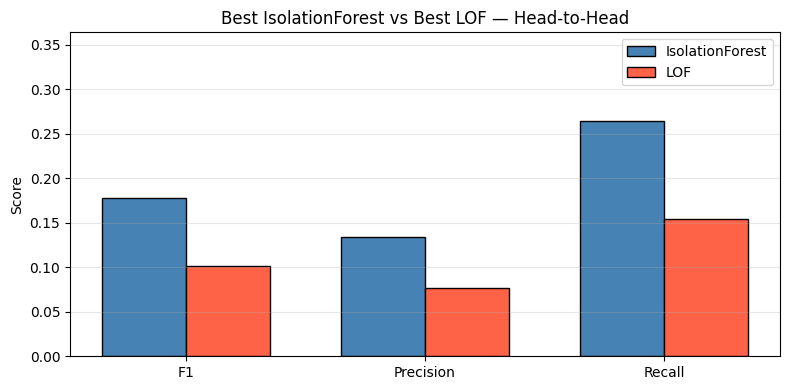

In [21]:
# ── Side-by-side comparison (Isagani) ────────────────────────────────────────
comparison_df = if_df.rename(columns={
    'f1': 'IF_f1', 'precision': 'IF_precision',
    'recall': 'IF_recall', 'flagged': 'IF_flagged'
}).merge(
    lof_df.rename(columns={
        'f1': 'LOF_f1', 'precision': 'LOF_precision',
        'recall': 'LOF_recall', 'flagged': 'LOF_flagged'
    }),
    on='contamination'
)

print('IsolationForest vs LOF — Full Contamination Sweep Comparison:')
print(comparison_df.to_string(index=False))

# Determine winner
f1_if  = float(best_if_row['f1'])
f1_lof = float(best_nn_row['f1'])
f1_delta = f1_if - f1_lof

if abs(f1_delta) < 0.005:
    rec_if  = float(best_if_row['recall'])
    rec_lof = float(best_nn_row['recall'])
    WINNER = 'IsolationForest' if rec_if >= rec_lof else 'LOF'
    reason = f'F1 near-equal; winner decided by Recall ({"IF" if rec_if >= rec_lof else "LOF"} higher).'
elif f1_delta > 0:
    WINNER = 'IsolationForest'
    reason = f'IsolationForest leads by {f1_delta:.4f} F1 points.'
else:
    WINNER = 'LOF'
    reason = f'LOF leads by {abs(f1_delta):.4f} F1 points.'

BEST_CONTAMINATION = float(best_if_row['contamination']) if WINNER == 'IsolationForest' \
    else float(best_lof_contamination)

print(f'\n{"=" * 55}')
print(f'  RECOMMENDATION : {WINNER}')
print(f'  Reason         : {reason}')
print(f'  Best F1 (IF)   : {f1_if:.4f}')
print(f'  Best F1 (LOF)  : {f1_lof:.4f}')
print(f'{"=" * 55}')

# Head-to-head bar chart
metrics = ['f1', 'precision', 'recall']
x = np.arange(len(metrics))
width = 0.35

if_vals  = [float(best_if_row[m]) for m in metrics]
lof_vals = [float(best_nn_row[m]) for m in metrics]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, if_vals,  width, label='IsolationForest', color='steelblue', edgecolor='black')
ax.bar(x + width/2, lof_vals, width, label='LOF',             color='tomato',    edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['F1', 'Precision', 'Recall'])
ax.set_ylabel('Score')
ax.set_title('Best IsolationForest vs Best LOF — Head-to-Head')
ax.legend()
ax.set_ylim(0, max(max(if_vals), max(lof_vals)) + 0.1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 9: Export & Inference *(Isagani)*

In [22]:
# ── Export winning model (Isagani) ────────────────────────────────────────────
MODEL_DIR = DRIVE_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / 'outlier_forest.pkl'

export_model = best_if if WINNER == 'IsolationForest' else best_lof
export_model.fit(X)  # ensure fitted on full training set

joblib.dump(export_model, MODEL_PATH)
size_kb = MODEL_PATH.stat().st_size / 1024
print(f'Exported: {MODEL_PATH}')
print(f'Model   : {WINNER}  (contamination={BEST_CONTAMINATION})')
print(f'Size    : {size_kb:.1f} KB')

Exported: /Users/isaganijulian/Documents/GitHub/Guardian-Recruit-Fraud-Detection/models/outlier_forest.pkl
Model   : IsolationForest  (contamination=0.1)
Size    : 780.2 KB


In [23]:
# ── Inference functions ───────────────────────────────────────────────────────
# These mirror the interface in src/outlier_stream.py for the Fusion Layer.

def outlier_score(row: dict) -> float:
    """
    Returns fraud anomaly score for a single job posting row.
    Higher score = more anomalous = more likely fraudulent.
    """
    input_df = preprocess_row(row)
    return float(-export_model.decision_function(input_df)[0])


def outlier_predict(row: dict) -> int:
    """
    Returns 1 (anomaly / likely fraud) or 0 (normal / likely legitimate).
    """
    input_df = preprocess_row(row)
    return 1 if export_model.predict(input_df)[0] == -1 else 0


# ── Demo ──────────────────────────────────────────────────────────────────────
test_cases = [
    ({'salary_range': '500000-1000000', 'employment_type': 'Unknown',
      'has_company_logo': 0, 'required_education': 'Unknown'},
     'Suspicious: extreme salary, no logo, no education requirement'),
    ({'salary_range': '60000-90000', 'employment_type': 'Full-time',
      'has_company_logo': 1, 'required_education': "Bachelor's Degree"},
     'Legitimate: normal salary, has logo, specifies education'),
    ({'salary_range': None, 'employment_type': None,
      'has_company_logo': 0, 'required_education': None},
     'Suspicious: all fields missing, no logo'),
]

print('Inference Demo:')
print('=' * 65)
for row, desc in test_cases:
    score = outlier_score(row)
    label = outlier_predict(row)
    print(f'\n[{desc}]')
    print(f'  Anomaly Score : {score:.4f}  (higher = more suspicious)')
    print(f'  Prediction    : {"FRAUD FLAGGED" if label == 1 else "NORMAL"}')

Inference Demo:

[Suspicious: extreme salary, no logo, no education requirement]
  Anomaly Score : 0.1184  (higher = more suspicious)
  Prediction    : FRAUD FLAGGED

[Legitimate: normal salary, has logo, specifies education]
  Anomaly Score : -0.0785  (higher = more suspicious)
  Prediction    : NORMAL

[Suspicious: all fields missing, no logo]
  Anomaly Score : -0.0202  (higher = more suspicious)
  Prediction    : NORMAL


---
## Summary: Phase 3 Deliverables Checklist

| Deliverable | What We Did | Owner |
|---|---|---|
| **Feature Selection & Engineering** | Selected 4 structured features with domain justification; salary midpoint processing; ordinal encoding for employment type and education; mutual information scoring to confirm predictive value | Kusuma |
| **Hyperparameter Tuning** | Contamination sweep [0.01–0.10] for both models; n_neighbors sweep [10–30] for LOF; selected best config per model by validation F1 | Isagani |
| **Validation Techniques** | Fixed 80/20 stratified val split for tuning; 5-Fold Stratified CV on full training data to confirm generalisation | Isagani |
| **Comprehensive Metrics** | Precision, Recall, F1 per class; confusion matrices with TP/TN/FP/FN breakdown; ROC-AUC; Precision-Recall curve; percentile-based threshold analysis for FP vs FN tradeoff | Isagani |

### Note on Model Performance
Unsupervised anomaly detection on 4 structured features yields lower absolute F1 scores than the supervised NLP stream — this is expected. Stream B's value is in its **complementary signal**: it flags structurally suspicious postings (missing salary, no company logo) that text alone might miss. The two streams are combined in the Fusion Layer (`04_fusion_layer_shap.ipynb`) for a stronger ensemble prediction.